서비스 이용 기간별 월 평균 이용량 분포

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# =========================
# ✅ Mac 한글 폰트 설정
# =========================
plt.rcParams["font.family"] = "AppleGothic"      # 맥 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 깨짐 방지


In [2]:
# 파일 경로들 (필요 시 경로만 수정)
path_2302_2304 = 'TPS_cancel_202302_202304_p_mt.csv'
#path_2305_2307 = 'TPS_cancel_202305_202307_p_mt.csv'
#path_2308_2310 = 'TPS_cancel_202308_202310_p_mt.csv'

# 각 파일을 기간 변수명으로 로딩
df_2302_2304 = pd.read_csv(path_2302_2304)
# df_2305_2307 = pd.read_csv(path_2305_2307)
# df_2308_2310 = pd.read_csv(path_2308_2310)

In [3]:
#결측치 싹 밀자 
# 1) 빈 문자열 / 공백 문자열을 NaN으로 통일
df_tmp = df_2302_2304.replace(r'^\s*$', np.nan, regex=True)

# 2) NaN 포함 행 전부 삭제
df_clean_2302_2304 = df_tmp.dropna().reset_index(drop=True)

# 3) 삭제 전/후 행 수 확인
print("삭제 전 행 수:", df_2302_2304.shape[0])
print("삭제 후 행 수:", df_clean_2302_2304.shape[0])
print("삭제된 행 수:", df_2302_2304.shape[0] - df_clean_2302_2304.shape[0])

삭제 전 행 수: 3156481
삭제 후 행 수: 3156474
삭제된 행 수: 7


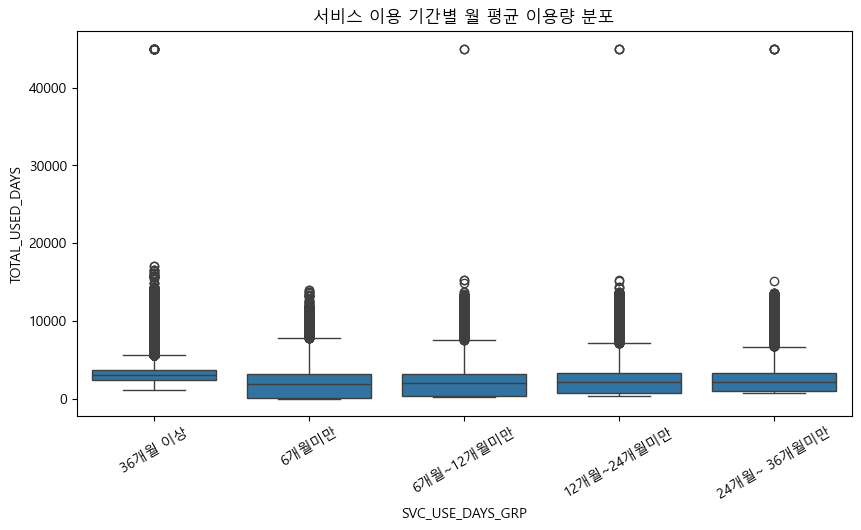

In [4]:

plt.figure(figsize=(10, 5))
sns.boxplot(
    x='SVC_USE_DAYS_GRP',
    y='TOTAL_USED_DAYS',
    data=df_clean_2302_2304
)
plt.xticks(rotation=30)
plt.title("서비스 이용 기간별 월 평균 이용량 분포")
plt.show()

#이상치가 너무 큼 


Categorical 매칭 실패(NaN) 개수: 0
그룹별 개수:
 SVC_USE_DAYS_GRP
36개월 이상        2150844
12개월~24개월미만     337553
24개월~36개월미만     331684
6개월미만           172352
6개월~12개월미만      164041
Name: count, dtype: int64

[IQR 제거 후] 행 수: 3139093


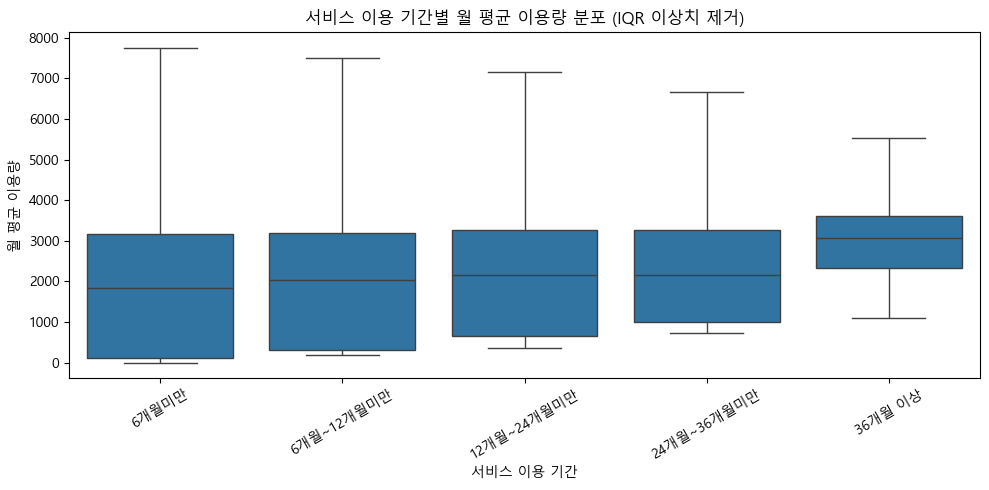

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# 0) 라벨 정규화: 앞뒤 공백 제거 + '~' 주변 공백 통일
# =========================================================
df_clean_2302_2304["SVC_USE_DAYS_GRP"] = (
    df_clean_2302_2304["SVC_USE_DAYS_GRP"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s*~\s*", "~", regex=True)  # '~' 앞뒤 공백 제거
    .str.replace(r"\s+", " ", regex=True)     # 연속 공백 1칸으로
)

# =========================================================
# 1) 기간 순서 정의
# =========================================================
order = [
    "6개월미만",
    "6개월~12개월미만",
    "12개월~24개월미만",
    "24개월~36개월미만",
    "36개월 이상"
]

# =========================================================
# 2) SVC_USE_DAYS_GRP를 순서형 범주로 변환 (x축 순서 고정)
#    - order에 없는 값은 NaN이 될 수 있음
# =========================================================
df_clean_2302_2304["SVC_USE_DAYS_GRP"] = pd.Categorical(
    df_clean_2302_2304["SVC_USE_DAYS_GRP"],
    categories=order,
    ordered=True
)

# (권장) 매칭 실패(=NaN) 확인
print("Categorical 매칭 실패(NaN) 개수:", df_clean_2302_2304["SVC_USE_DAYS_GRP"].isna().sum())
print("그룹별 개수:\n", df_clean_2302_2304["SVC_USE_DAYS_GRP"].value_counts(dropna=False))

# =========================================================
# 3) IQR로 이상치 제거 함수 (그룹별 기준)
#    - 그룹 내에서 Q1, Q3, IQR 계산 → 1.5*IQR 범위 밖 제거
# =========================================================
def remove_outliers_iqr(df, group_col, value_col):
    result = []

    # groupby 시 NaN 그룹은 제외되므로, 필요 시 사전에 dropna 권장
    for g, sub in df.groupby(group_col):
        # 빈 그룹 방지
        if sub.empty:
            continue

        Q1 = sub[value_col].quantile(0.25)
        Q3 = sub[value_col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # IQR 범위 안의 데이터만 남김
        filtered = sub[(sub[value_col] >= lower) & (sub[value_col] <= upper)]
        result.append(filtered)

    return pd.concat(result, ignore_index=True)

# 이상치 제거 적용 (분석/시각화용 데이터셋)
df_no_outlier_2302_2304 = remove_outliers_iqr(
    df_clean_2302_2304.dropna(subset=["SVC_USE_DAYS_GRP", "TOTAL_USED_DAYS"]),
    "SVC_USE_DAYS_GRP",
    "TOTAL_USED_DAYS"
)

print("\n[IQR 제거 후] 행 수:", len(df_no_outlier_2302_2304))

# =========================================================
# 4) 박스플롯 출력
#    IQR 제거본: 실제로 이상치가 제거된 df_no_outlier로 그림
# =========================================================

# 실제 이상치 제거 후 ----
plt.figure(figsize=(10, 5))
sns.boxplot(
    x="SVC_USE_DAYS_GRP",
    y="TOTAL_USED_DAYS",
    data=df_no_outlier_2302_2304,
    order=order,
    showfliers=False  # 제거 후에도 가독성 유지용(사실상 큰 의미 없음)
)
plt.xticks(rotation=30)
plt.title("서비스 이용 기간별 월 평균 이용량 분포 (IQR 이상치 제거)")
plt.xlabel("서비스 이용 기간")
plt.ylabel("월 평균 이용량")
plt.tight_layout()
plt.show()


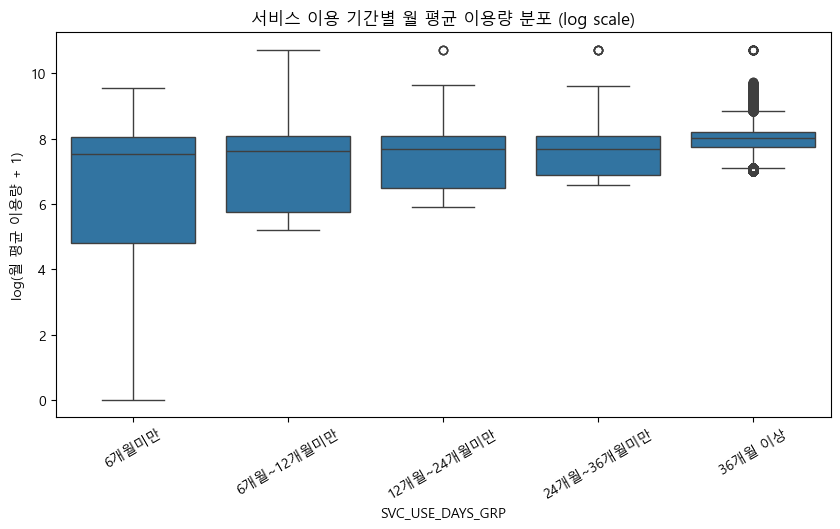

In [21]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='SVC_USE_DAYS_GRP',
    y=np.log1p(df_clean_2302_2304['TOTAL_USED_DAYS']),
    data=df_clean_2302_2304
)
plt.xticks(rotation=30)
plt.title("서비스 이용 기간별 월 평균 이용량 분포 (log scale)")
plt.ylabel("log(월 평균 이용량 + 1)")
plt.show()


In [6]:
# 로그 변환 컬럼 추가
df_no_outlier_2302_2304["log_TOTAL_USED_DAYS"] = np.log1p(
    df_no_outlier_2302_2304["TOTAL_USED_DAYS"]
)


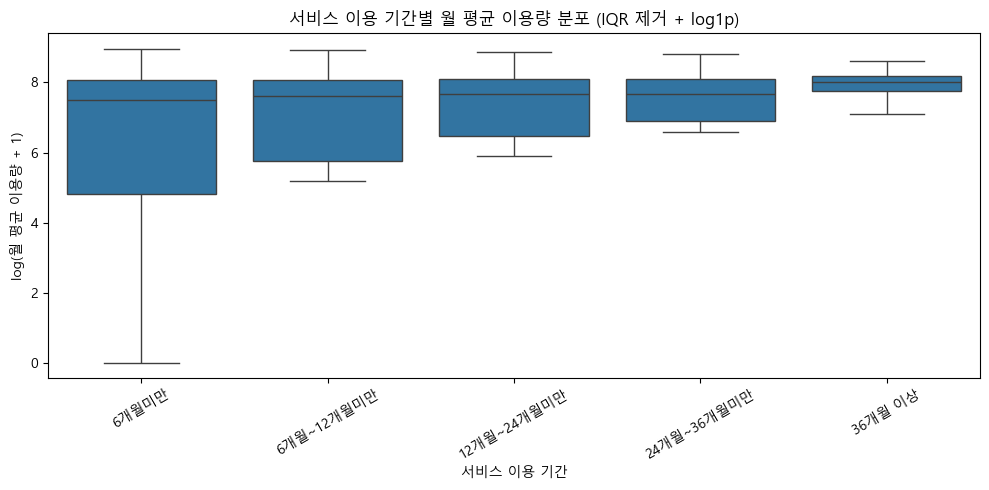

In [7]:

plt.figure(figsize=(10, 5))
sns.boxplot(
    x="SVC_USE_DAYS_GRP",
    y="log_TOTAL_USED_DAYS",
    data=df_no_outlier_2302_2304,
    order=order,
    showfliers=False
)

plt.xticks(rotation=30)
plt.title("서비스 이용 기간별 월 평균 이용량 분포 ")
plt.xlabel("서비스 이용 기간")
plt.ylabel("log(월 평균 이용량 + 1)") # 0값을 가지는걸 예방 
plt.tight_layout()
plt.show()


In [12]:
#가설검정 
from scipy.stats import shapiro

# 전체 데이터로 Shapiro–Wilk 정규성 검정
stat, p_value = shapiro(df_no_outlier_2302_2304["log_TOTAL_USED_DAYS"])

print(f"Shapiro-Wilk statistic: {stat}")
print(f"Shapiro-Wilk p-value: {p_value}")

#Shapiro–Wilk 검정은 표본 수가 커질수록 극도로 민감
# 데이터 개수 너무 많아서 -> P-VALUE 너무 작아짐 

Shapiro-Wilk statistic: 0.7047110408928016
Shapiro-Wilk p-value: 2.4381300263449924e-202


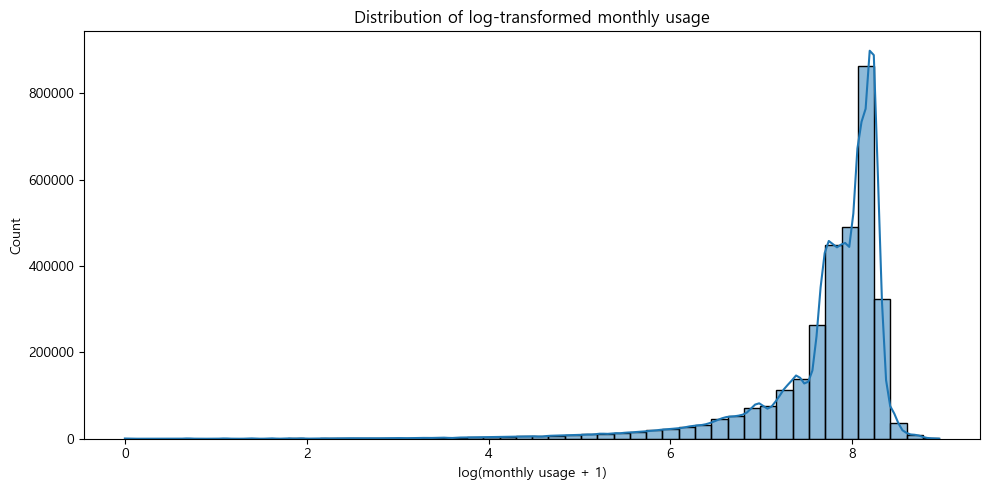

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(
    df_no_outlier_2302_2304["log_TOTAL_USED_DAYS"],
    bins=50,
    kde=True
)

plt.title("Distribution of log-transformed monthly usage")
plt.xlabel("log(monthly usage + 1)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


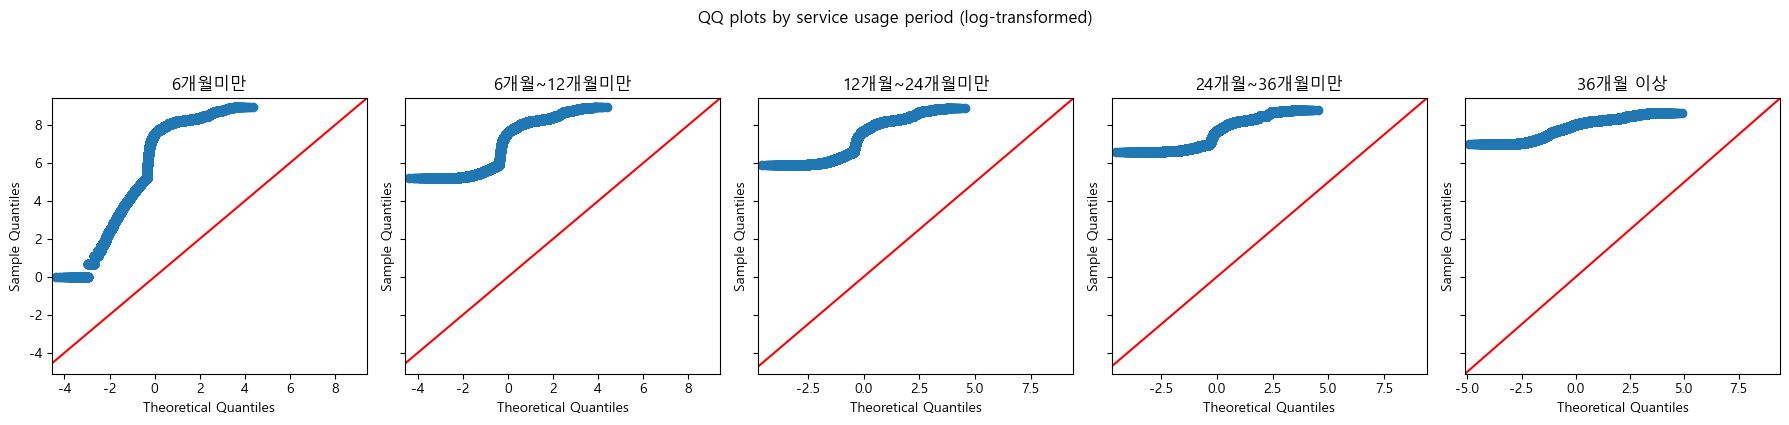

In [19]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

groups = order  # 기간 순서

fig, axes = plt.subplots(1, len(groups), figsize=(18, 4), sharey=True)

for ax, g in zip(axes, groups):
    data_g = df_no_outlier_2302_2304.loc[
        df_no_outlier_2302_2304["SVC_USE_DAYS_GRP"] == g,
        "log_TOTAL_USED_DAYS"
    ].dropna()  # 전체 데이터 사용

    sm.qqplot(data_g, line="45", ax=ax)
    ax.set_title(g)

plt.suptitle("QQ plots by service usage period (log-transformed)", y=1.05)
plt.tight_layout()
plt.show()


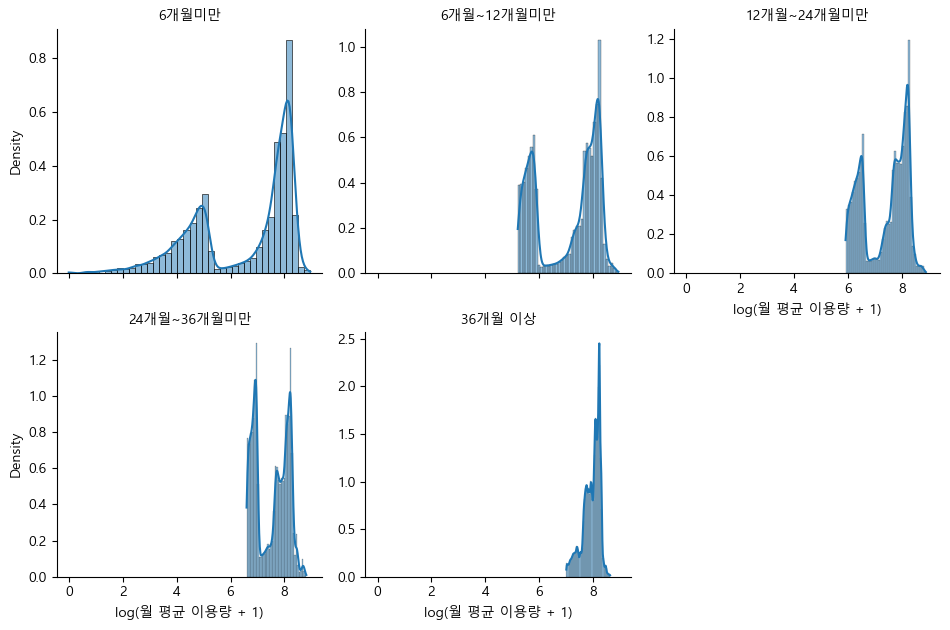

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 보기 좋게 순서 고정
df_plot = df_no_outlier_2302_2304.copy()
df_plot["SVC_USE_DAYS_GRP"] = pd.Categorical(df_plot["SVC_USE_DAYS_GRP"], categories=order, ordered=True)

g = sns.FacetGrid(
    df_plot,
    col="SVC_USE_DAYS_GRP",
    col_order=order,
    col_wrap=3,
    height=3.2,
    sharex=True,
    sharey=False  # 그룹별 표본 수가 달라서 y축 공유하면 왜곡될 수 있음
)

g.map_dataframe(
    sns.histplot,
    x="log_TOTAL_USED_DAYS",
    bins=40,
    stat="density",   # ✅ y축을 '밀도'로 통일(그룹별 표본 수 차이 영향 감소)
    kde=True
)

g.set_axis_labels("log(월 평균 이용량 + 1)", "Density")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()


In [21]:
from scipy.stats import levene

# 그룹별 데이터 분리
grouped_data = [
    df_no_outlier_2302_2304.loc[
        df_no_outlier_2302_2304["SVC_USE_DAYS_GRP"] == g,
        "log_TOTAL_USED_DAYS"
    ].dropna()
    for g in order
]

# Levene test
stat, p_value = levene(*grouped_data)

print(f"Levene statistic: {stat}")
print(f"Levene p-value: {p_value}")


Levene statistic: 414087.21837003325
Levene p-value: 0.0


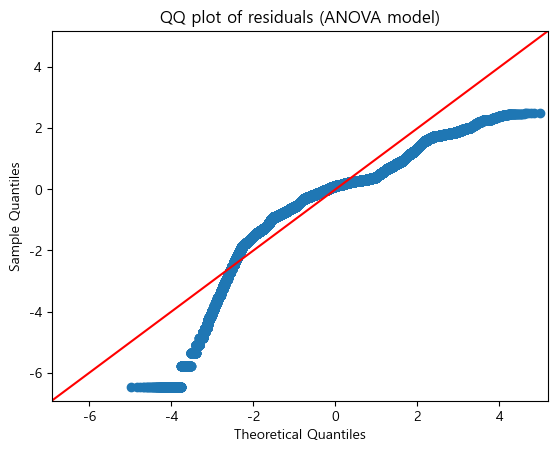

In [23]:
#ANOVA는 잔차로 정규분포 확인해야돼... 
import statsmodels.api as sm
import statsmodels.formula.api as smf

df_tmp = df_no_outlier_2302_2304.copy()

# 범주형 처리
df_tmp["SVC_USE_DAYS_GRP"] = df_tmp["SVC_USE_DAYS_GRP"].astype("category")

model = smf.ols("log_TOTAL_USED_DAYS ~ C(SVC_USE_DAYS_GRP)", data=df_tmp).fit()
resid = model.resid

sm.qqplot(resid, line="45")
plt.title("QQ plot of residuals (ANOVA model)")
plt.show()


In [24]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 분석용 데이터 (결측 제거)
df_anova = df_no_outlier_2302_2304[[
    "SVC_USE_DAYS_GRP",
    "log_TOTAL_USED_DAYS"
]].dropna().copy()

# 범주형으로 명시 (기간 순서 유지)
df_anova["SVC_USE_DAYS_GRP"] = pd.Categorical(
    df_anova["SVC_USE_DAYS_GRP"],
    categories=order,
    ordered=True
)

# one-way ANOVA (OLS)
model = smf.ols(
    "log_TOTAL_USED_DAYS ~ C(SVC_USE_DAYS_GRP)",
    data=df_anova
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


                           sum_sq         df              F  PR(>F)
C(SVC_USE_DAYS_GRP)  5.008733e+05        4.0  284373.973383     0.0
Residual             1.382234e+06  3139088.0            NaN     NaN


In [25]:
F_value = anova_table["F"].iloc[0]
p_value = anova_table["PR(>F)"].iloc[0]

print(f"F statistic: {F_value}")
print(f"p-value: {p_value}")


F statistic: 284373.97338340763
p-value: 0.0


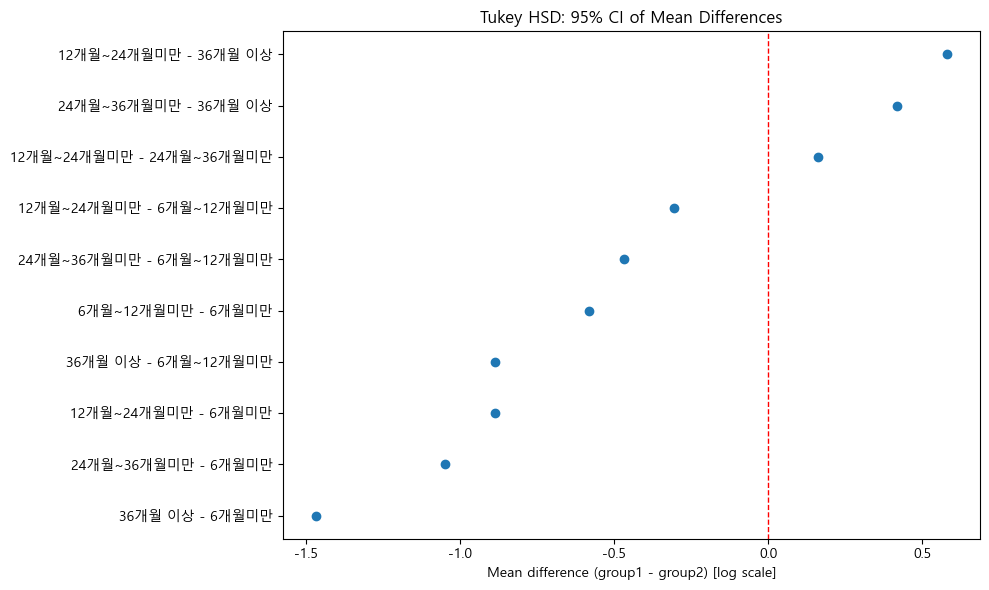

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1) Tukey 실행 (ANOVA에 쓴 df_anova를 그대로 쓰는 게 안전)
tukey = pairwise_tukeyhsd(
    endog=df_anova["log_TOTAL_USED_DAYS"],
    groups=df_anova["SVC_USE_DAYS_GRP"],
    alpha=0.05 # 유의수준 5프로 -> 신뢰수준 : 95프로
)

# 2) 결과를 배열로 꺼내기
# tukey.summary().data = [header, row1, row2, ...]
rows = tukey.summary().data[1:]

labels = [f"{r[0]} - {r[1]}" for r in rows]  # group1 - group2
meandiff = np.array([float(r[2]) for r in rows])
lower    = np.array([float(r[4]) for r in rows])
upper    = np.array([float(r[5]) for r in rows])

# 3) 보기 좋게 정렬(차이 큰 순)
order_idx = np.argsort(meandiff)
labels  = [labels[i] for i in order_idx]
meandiff = meandiff[order_idx]
lower    = lower[order_idx]
upper    = upper[order_idx]

# 4) 가로 에러바(신뢰구간) 플롯
y = np.arange(len(labels))

plt.figure(figsize=(10, 6))
plt.hlines(y, lower, upper)                          # CI 선
plt.plot(meandiff, y, "o")                           # 평균차 점
plt.axvline(0, color="red", linestyle="--", lw=1)    # 0 기준선

plt.yticks(y, labels, fontsize=10)
plt.xlabel("Mean difference (group1 - group2) [log scale]")
plt.title("Tukey HSD: 95% CI of Mean Differences")
plt.tight_layout()
plt.show()


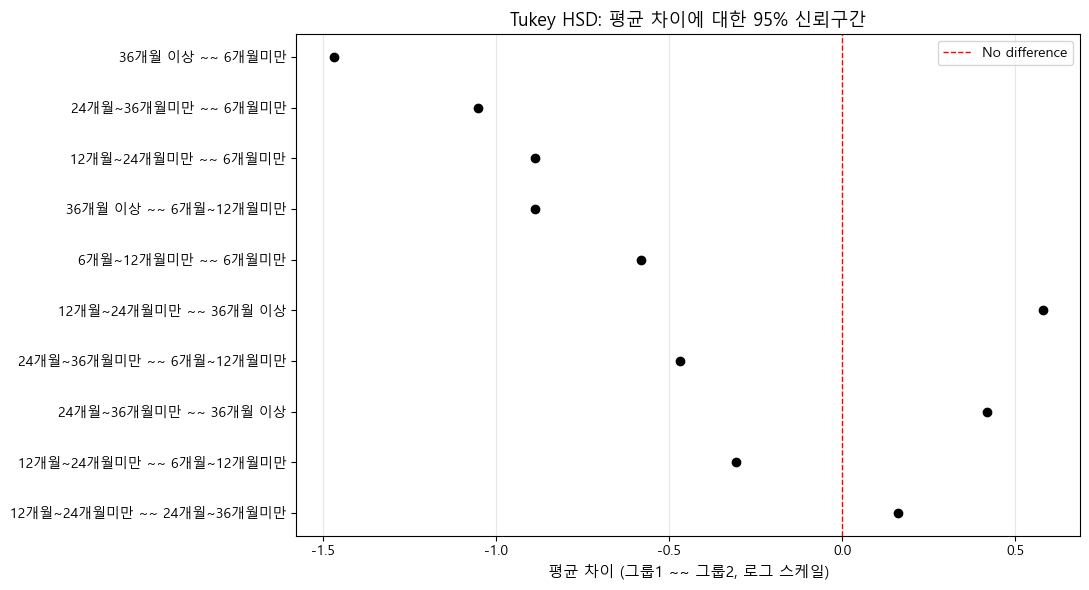

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1) Tukey HSD
tukey = pairwise_tukeyhsd(
    endog=df_anova["log_TOTAL_USED_DAYS"],
    groups=df_anova["SVC_USE_DAYS_GRP"],
    alpha=0.05  # 유의수준 5% → 신뢰수준 95%
)

# 2) 결과 추출
rows = tukey.summary().data[1:]

labels   = [f"{r[0]} ~~ {r[1]}" for r in rows]
meandiff = np.array([float(r[2]) for r in rows])
lower    = np.array([float(r[4]) for r in rows])
upper    = np.array([float(r[5]) for r in rows])

# 3) 절댓값 기준 정렬 (차이 큰 비교가 위로 오게)
order_idx = np.argsort(np.abs(meandiff))

labels   = [labels[i] for i in order_idx]
meandiff = meandiff[order_idx]
lower    = lower[order_idx]
upper    = upper[order_idx]

y = np.arange(len(labels))

# 4) Plot
plt.figure(figsize=(11, 6))

# 신뢰구간
plt.hlines(
    y=y,
    xmin=lower,
    xmax=upper,
    color="gray",
    linewidth=2
)

# 평균 차이 점
plt.scatter(
    meandiff,
    y,
    color="black",
    zorder=3
)

# 0 기준선
plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=1,
    label="No difference"
)

plt.yticks(y, labels, fontsize=10)
plt.xlabel("평균 차이 (그룹1 ~~ 그룹2, 로그 스케일)", fontsize=11)
plt.title("Tukey HSD: 평균 차이에 대한 95% 신뢰구간", fontsize=13)

plt.grid(axis="x", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [33]:
#36개월이상 vs 나머지 
from scipy.stats import ttest_ind

group_long = df_no_outlier_2302_2304.loc[
    df_no_outlier_2302_2304["SVC_USE_DAYS_GRP"] == "36개월 이상",
    "log_TOTAL_USED_DAYS"
]

group_others = df_no_outlier_2302_2304.loc[
    df_no_outlier_2302_2304["SVC_USE_DAYS_GRP"] != "36개월 이상",
    "log_TOTAL_USED_DAYS"
]

t_stat, p_value = ttest_ind(
    group_long,
    group_others,
    equal_var=False  # Welch t-test
)

print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}")


t-statistic: 627.2810879460365
p-value: 0.0


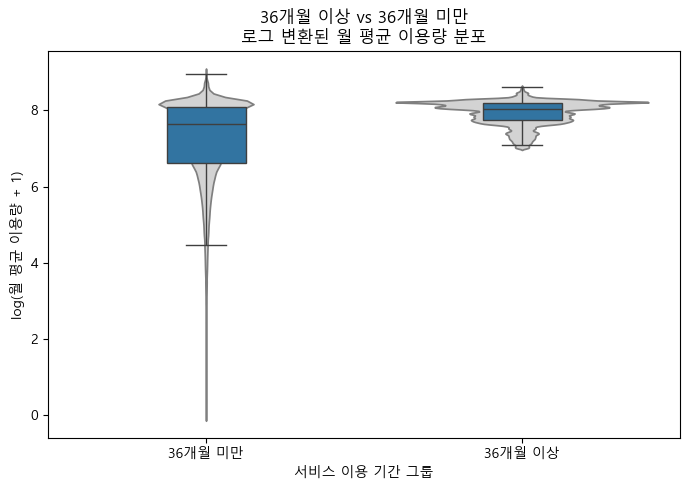

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# 비교용 데이터 생성
df_vis = df_no_outlier_2302_2304.copy()
df_vis["GROUP_BINARY"] = df_vis["SVC_USE_DAYS_GRP"].apply(
    lambda x: "36개월 이상" if x == "36개월 이상" else "36개월 미만"
)

plt.figure(figsize=(7, 5))

sns.violinplot(
    x="GROUP_BINARY",
    y="log_TOTAL_USED_DAYS",
    data=df_vis,
    inner=None,
    color="lightgray"
)

sns.boxplot(
    x="GROUP_BINARY",
    y="log_TOTAL_USED_DAYS",
    data=df_vis,
    width=0.25,
    showfliers=False
)

plt.title("36개월 이상 vs 36개월 미만\n로그 변환된 월 평균 이용량 분포")
plt.xlabel("서비스 이용 기간 그룹")
plt.ylabel("log(월 평균 이용량 + 1)")
plt.tight_layout()
plt.show()


In [35]:
from scipy.stats import shapiro

# 36개월 이상
stat_long, p_long = shapiro(group_long.sample(5000, random_state=42))
print("36개월 이상 Shapiro p-value:", p_long)

# 36개월 미만
stat_others, p_others = shapiro(group_others.sample(5000, random_state=42))
print("36개월 미만 Shapiro p-value:", p_others)


36개월 이상 Shapiro p-value: 2.764542893854167e-44
36개월 미만 Shapiro p-value: 4.958658943500197e-56


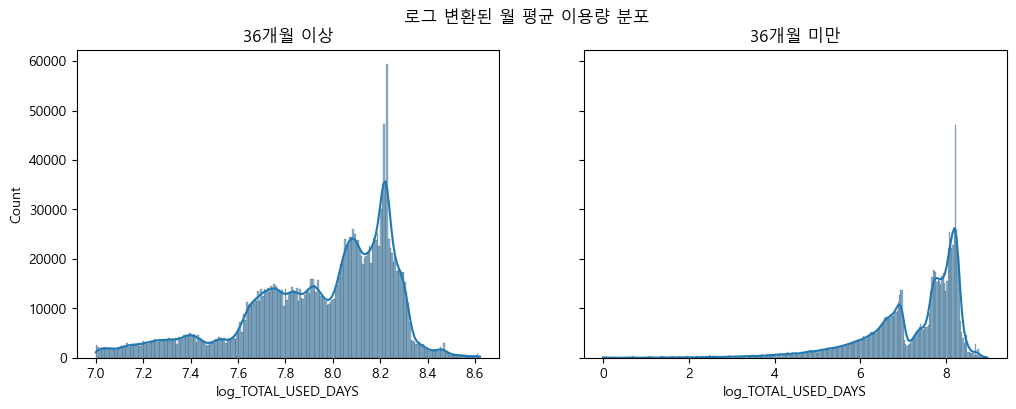

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.histplot(group_long, kde=True, ax=axes[0])
axes[0].set_title("36개월 이상")

sns.histplot(group_others, kde=True, ax=axes[1])
axes[1].set_title("36개월 미만")

plt.suptitle("로그 변환된 월 평균 이용량 분포")
plt.show()


In [37]:
#두 집단 평균 차이가 표준편차 기준으로 얼마나 큰가
import numpy as np

# 평균
mean_long   = group_long.mean()
mean_others = group_others.mean()

# 표준편차
std_long   = group_long.std(ddof=1)
std_others = group_others.std(ddof=1)

# 표본 수
n_long   = group_long.shape[0]
n_others = group_others.shape[0]

# pooled standard deviation
pooled_std = np.sqrt(
    ((n_long - 1) * std_long**2 + (n_others - 1) * std_others**2)
    / (n_long + n_others - 2)
)

# Cohen's d
cohens_d = (mean_long - mean_others) / pooled_std

print(f"Cohen's d: {cohens_d}")


Cohen's d: 1.0488279171472872
